In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from matplotlib.ticker import ScalarFormatter

drive.mount('/content/drive')

Mounted at /content/drive


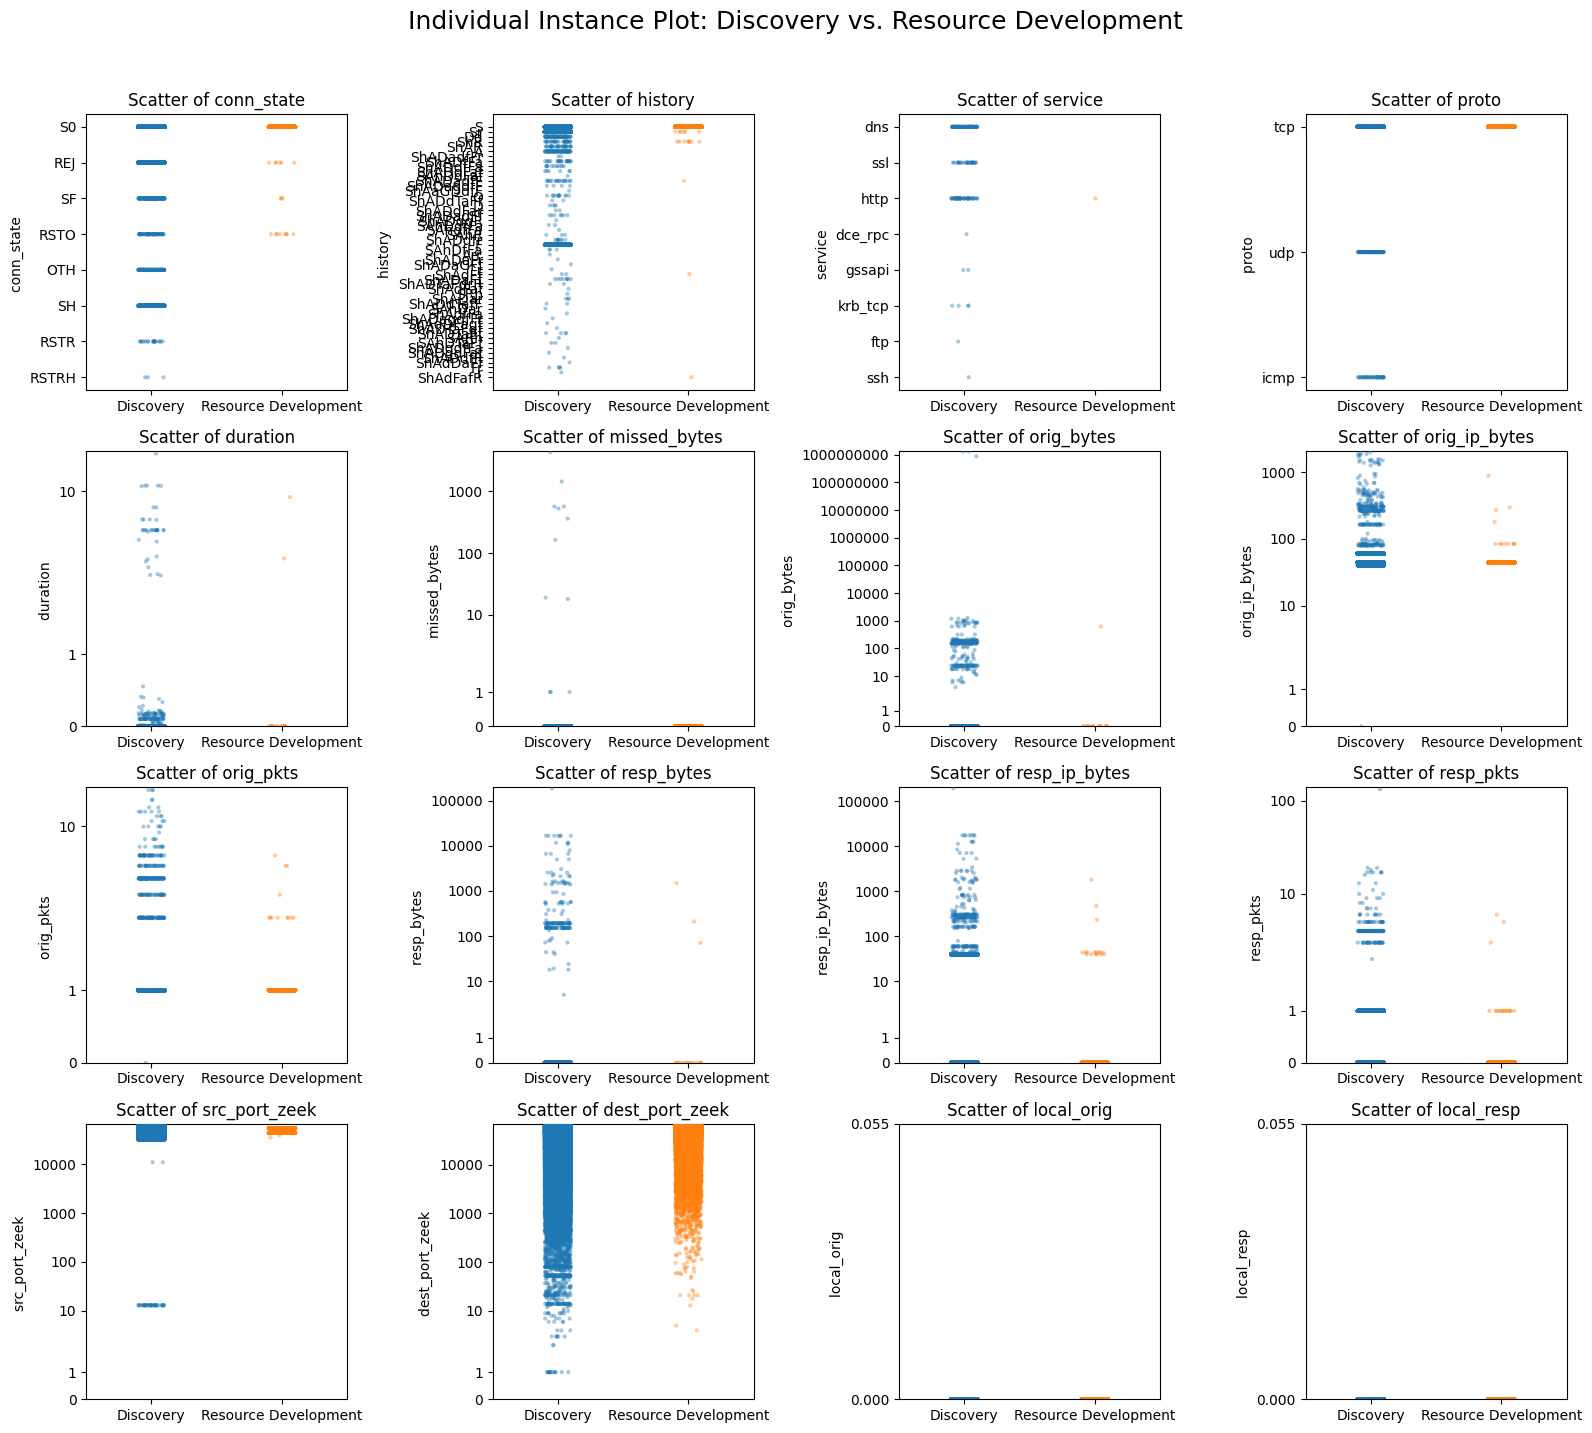

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

df = pd.read_csv('/content/drive/MyDrive/zeek24data/zeekdata_combined.csv')

#Filter for only the two classes
target_classes = ['Discovery', 'Resource Development']
df_filtered = df[df['label_tactic'].isin(target_classes)]

#List of features that wanted to be comapared
features_to_plot = [
    'conn_state','history','service', 'proto','duration', 'missed_bytes',
    'orig_bytes', 'orig_ip_bytes', 'orig_pkts',
    'resp_bytes', 'resp_ip_bytes', 'resp_pkts',
    'src_port_zeek', 'dest_port_zeek', 'local_orig', 'local_resp'
]

#Set up the plotting grid
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

# Loop through and plot each feature as a scatter/strip plot
for i, feature in enumerate(features_to_plot):
    if feature in df_filtered.columns:
        # A stripplot plots every single row as an individual (x,y) dot
        sns.stripplot(
            data=df_filtered,
            x='label_tactic',      # X-axis is the MITRE Tactic
            y=feature,             # Y-axis is the feature value
            hue='label_tactic',    # Color by Tactic
            ax=axes[i],
            palette=['#1f77b4', '#ff7f0e'], # Blue and Orange
            alpha=0.4,             # Makes dots transparent to see density
            jitter=True,           # Spreads dots out horizontally so they don't form a single vertical line
            size=3,                # Size of the dots
            legend=False
        )

        axes[i].set_title(f'Scatter of {feature}', fontsize=12)
        axes[i].set_xlabel('')

        if pd.api.types.is_numeric_dtype(df_filtered[feature]):
            axes[i].set_yscale('symlog')
            axes[i].set_ylim(bottom=0)

            for axis in [axes[i].yaxis]:
                formatter = ScalarFormatter()
                formatter.set_scientific(False)  # Turn off scientific notation completely
                axis.set_major_formatter(formatter)

            axes[i].set_ylabel(f'{feature} ')
        else:
            axes[i].set_ylabel(f'{feature} ')

plt.suptitle('Individual Instance Plot: Discovery vs. Resource Development', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

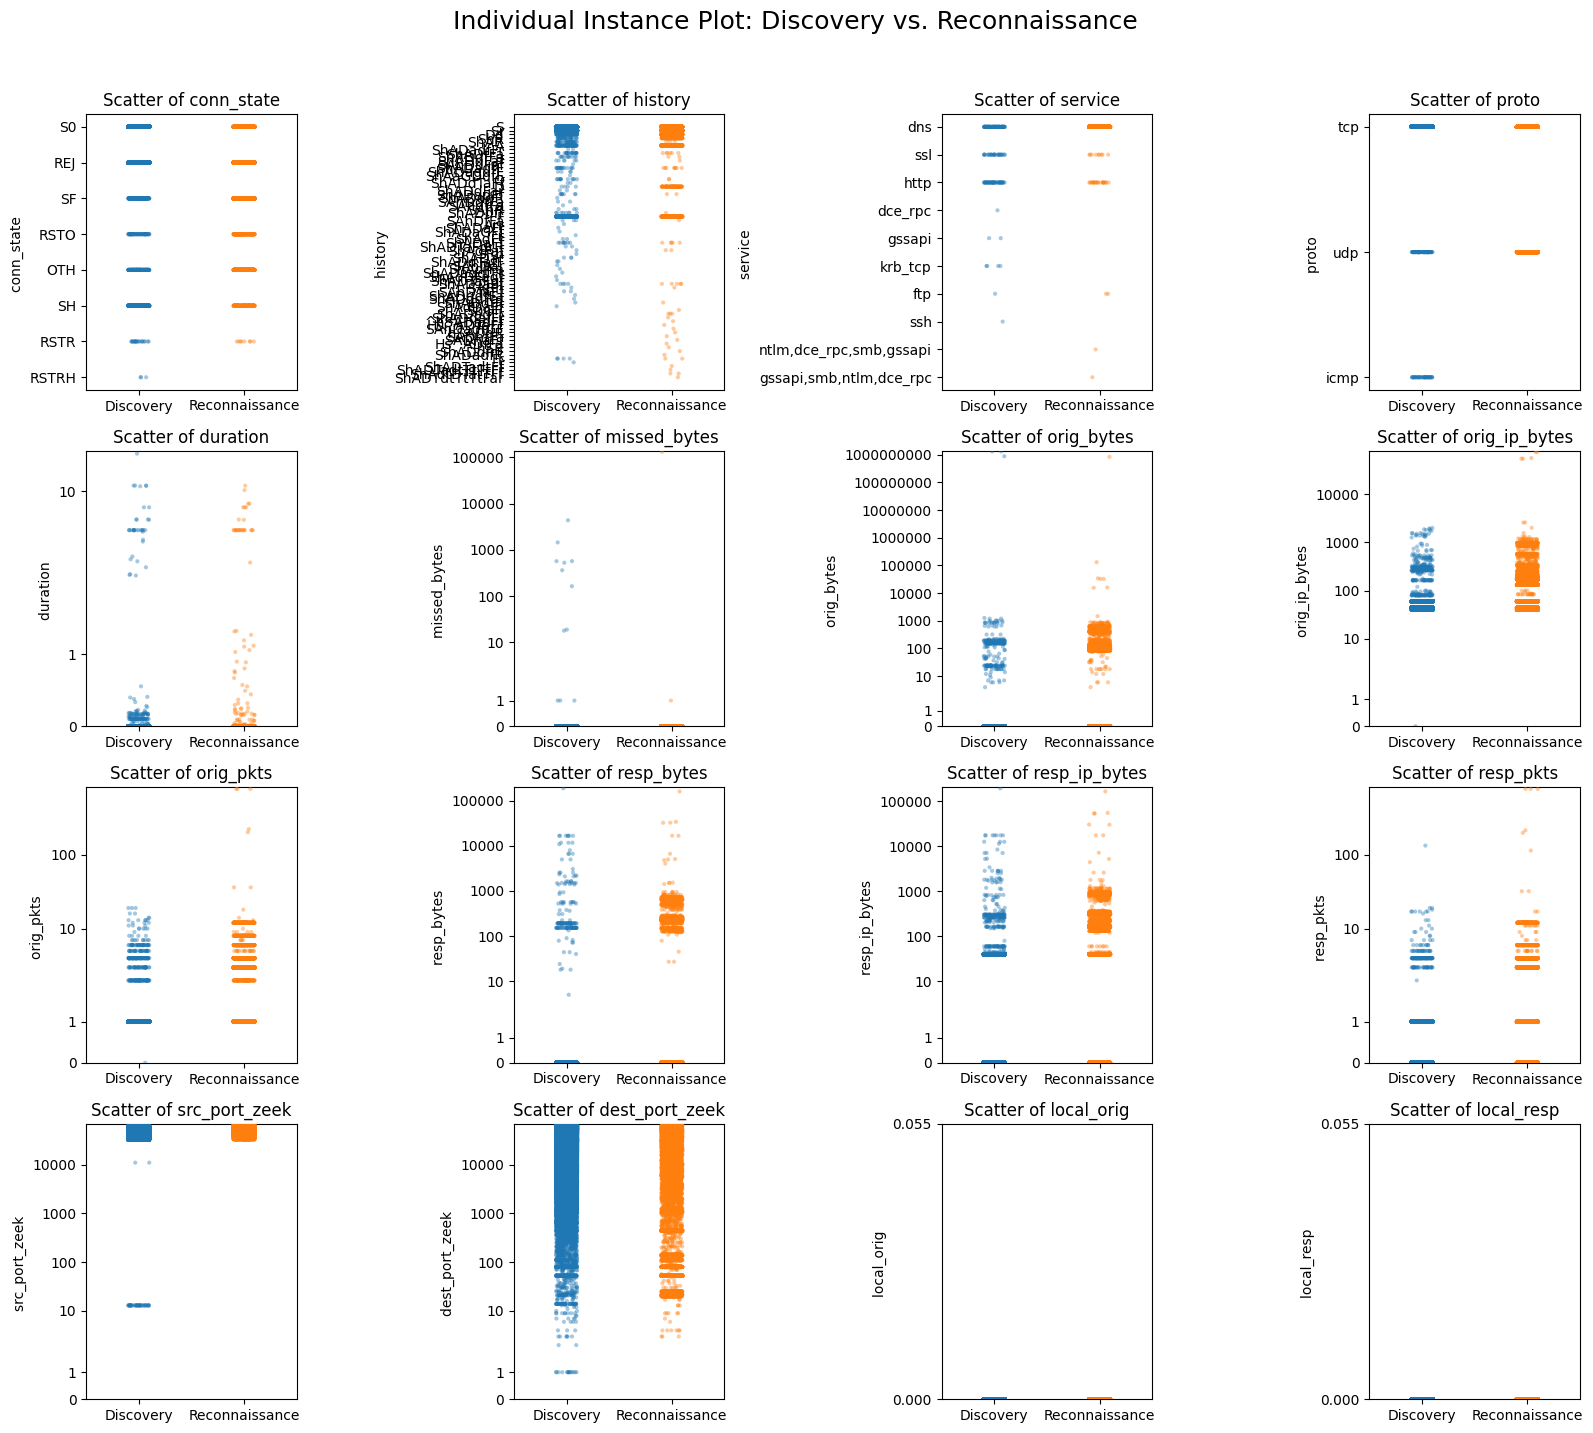

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

df = pd.read_csv('/content/drive/MyDrive/zeek24data/zeekdata_combined.csv')

# Filter for only the two classes
target_classes = ['Discovery', 'Reconnaissance']
df_filtered = df[df['label_tactic'].isin(target_classes)]

# List of features to be compared
features_to_plot = [
    'conn_state','history','service', 'proto','duration', 'missed_bytes',
    'orig_bytes', 'orig_ip_bytes', 'orig_pkts',
    'resp_bytes', 'resp_ip_bytes', 'resp_pkts',
    'src_port_zeek', 'dest_port_zeek', 'local_orig', 'local_resp'
]

# Set up the plotting grid (3x4 grid for 12 features)
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

# Loop through and plot each feature as a scatter/strip plot
for i, feature in enumerate(features_to_plot):
    if feature in df_filtered.columns:
        # A stripplot plots every single row as an individual (x,y) dot
        sns.stripplot(
            data=df_filtered,
            x='label_tactic',      # X-axis is the MITRE Tactic
            y=feature,             # Y-axis is the feature value
            hue='label_tactic',    # Color by Tactic
            ax=axes[i],
            palette=['#1f77b4', '#ff7f0e'], # Blue and Orange
            alpha=0.4,             # Makes dots transparent to see density
            jitter=True,           # Spreads dots out horizontally so they don't form a single vertical line
            size=3,                # Size of the dots
            legend=False
        )

        axes[i].set_title(f'Scatter of {feature}', fontsize=12)
        axes[i].set_xlabel('')

        if pd.api.types.is_numeric_dtype(df_filtered[feature]):
            axes[i].set_yscale('symlog')

            axes[i].set_ylim(bottom=0)

            for axis in [axes[i].yaxis]:
                formatter = ScalarFormatter()
                formatter.set_scientific(False)
                axis.set_major_formatter(formatter)

            axes[i].set_ylabel(f'{feature} ')
        else:
            axes[i].set_ylabel(f'{feature} ')

plt.suptitle('Individual Instance Plot: Discovery vs. Reconnaissance', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()